# Gráficas con MatPlotLib

## Entender realmente qué es Matplotlib.

* `Matplotlib` no es ***“hacer gráficas”***, es un `sistema de dibujo`.
* Entendido esto, todo lo demás se vuelve lógico.
* `Figure`:
  - Es el lienzo completo.
  - Corresponde a `fig = plt.figure()`.
  - Es como una super hoja en blanco.
* `Axes`:
  - Es donde realmente se dibuja la gráfica.
  - Corresponde a `ax = fig.add_subplot()`.
  - Un error común: ***pensar que la gráfica es la figura***.
  - No, ***la gráfica vive dentro de los axes***.
  - ***Una figura puede tener múltiples axes***.
* ***Estado vs Orientado a Objetos***
* Hay dos formas de usar matplotlib:
  - Modo simple (stateful): `plt.plot(x, y)`.
  - Modo profesional (orientado a objetos): `fig, ax = plt.subplots()`, `ax.plot(x, y)`.
  - Es muy usada la segunda.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

## EJERCICIO 1 — Entendiendo la Estructura

* `x = np.linspace(0, 5, 100)`:
  - Genera 100 números entre 0 y 5, es decir 100 numeros equidistantes entre 0-5.
* `fig, ax = plt.subplots(figsize=(6,4))`:
  - Crea una figura `fig`.
  - Crea un área de gráfico `ax`.
  - `figsize=(6,4)` define el tamaño en pulgadas
* ***¿Por qué subplots() devuelve dos objetos?***
  - `plt.subplots() crea` una `Figure` uno o varios `Axes`.
  - Si hubiera múltiples ejes: `fig, ax = plt.subplots(2,2)`.
  - `ax` sería un array de objetos `Axes`.
* ***¿Por qué funciona?*** `plt.plot(x, y)`
  - Matplotlib tiene un "estado interno global".
  - Si no existe una figura, crea una automáticamente.
  - Pero en proyectos reales eso puede causar.
  - gráficos mezclados.
  - resultados inesperados.
  - bugs difíciles de rastrear

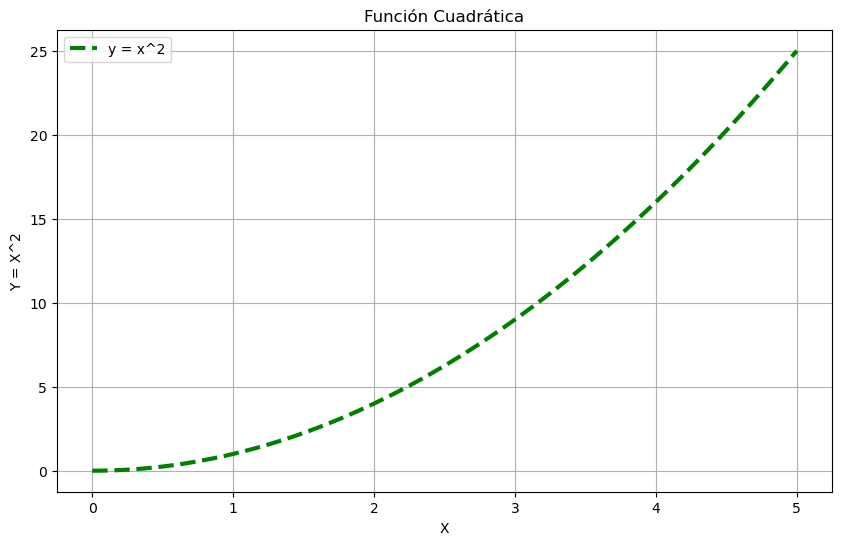

In [2]:
x = np.linspace(0, 5, 100)
y = x**2

# fig, ax = plt.subplots(figsize=(6,4))
fig, ax = plt.subplots(figsize=(10,6))

### Dibujamos la linea
# ax.plot(x, y)
ax.plot(
    x,
    y,
    linewidth=3, ### Grosor
    linestyle='--', ### Estilo
    color='green', ### Color
    label="y = x^2" ### etiqueta para la leyenda 
)

ax.set_title("Función Cuadrática")
ax.set_xlabel("X")
ax.set_ylabel("Y = X^2")

### Activa la cuadricula
ax.grid(True)

### Agregar leyenda
ax.legend()

plt.show()

* ¿Puede una Figure tener múltiples `Axes`?
  - De hecho, ese es el propósito principal de Figure.
  - Aquí `fig, ax = plt.subplots(2,2)`, tenemos una `Figure` y `4 Axes`.
* ¿Puede un `Axes` existir sin `Figure`?
  - Un `Axes` siempre pertenece a una `Figure`.
* ¿Qué crees que pasa si haces múltiples `ax.plot()` sobre el mismo `ax`?
  - Si hacemos `ax.plot(x, y1); ax.plot(x, y2) ; ax.plot(x, y3)`, todas las líneas se dibujan en el mismo sistema de coordenadas.
  - No se reemplaza, se agregan elementos.

## EJERCICIO 2 — Entendiendo la Estructura

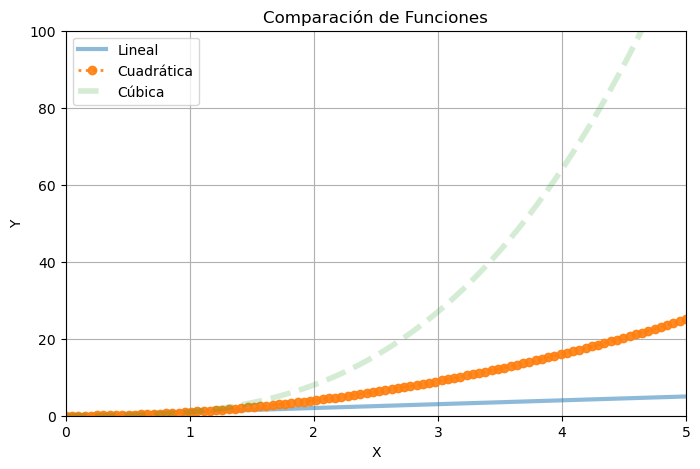

In [3]:
"""
1. Cambia grosor de línea (linewidth)
2. Agrega transparencia (alpha)
3. Usa diferentes estilos (--, :)
4. Agrega marcadores solo a una curva
5. Cambia límites manualmente con: ax.set_xlim() y ax.set_ylim().
"""
x = np.linspace(0, 5, 100)

fig, ax = plt.subplots(figsize=(8,5))

### Lineal (línea gruesa y con transparencia)
ax.plot(x, 
        x,
        linewidth=3,
        alpha=0.5,
        linestyle='-',
        label="Lineal")

### Cuadrática (línea punteada con marcador)
ax.plot(x, 
        x**2,
        linewidth=2,
        linestyle=":",
        alpha=0.9,
        marker='o',          # ← Marcador SOLO aquí
        markersize=6,
        label="Cuadrática")

### Cúbica (línea discontinua y más gruesa)
ax.plot(x, 
        x**3,
        linewidth=4,
        linestyle="--",
        alpha=0.2,
        label="Cúbica")

ax.set_title("Comparación de Funciones")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# 4️⃣ Límites manuales
ax.set_xlim(0, 5)
ax.set_ylim(0, 100)

ax.legend()
ax.grid(True)

plt.show()

* Cuando agregas múltiples `ax.plot()`, `Matplotlib` usa su ciclo interno de colores por defecto `(llamado tab10)`.
* Cada `Axes` tiene su propio `property cycle`.
* ***¿Crees que el color de la línea en fig2 empieza desde el mismo color inicial o continúa el ciclo donde se quedó?***
```python
fig1, ax1 = plt.subplots()
ax1.plot(x, x)

fig2, ax2 = plt.subplots()
ax2.plot(x, x)
```
* Cuando haces:
  - `ax1` tiene su ciclo de colores.
  - `ax2` tiene su propio ciclo independiente.
  - Cada Axes administra sus estilos internamente.

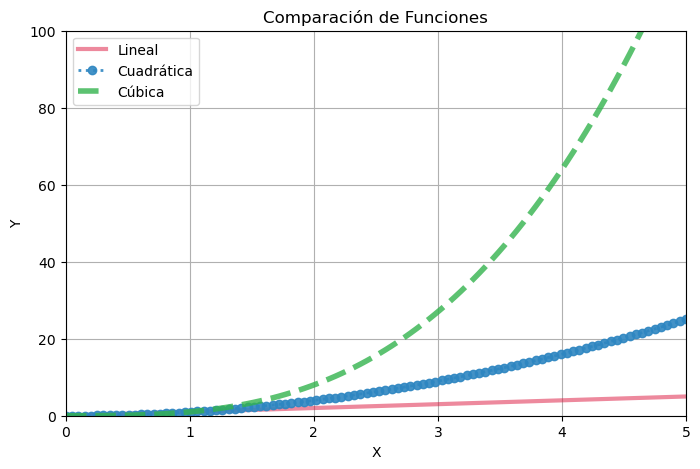

In [5]:
plt.rcParams['axes.prop_cycle']

## Cambiando el color
x = np.linspace(0, 5, 100)

fig, ax = plt.subplots(figsize=(8,5))

### Lineal (línea gruesa y con transparencia)
ax.plot(x, 
        x,
        linewidth=3,
        alpha=0.5,
        linestyle='-',
        color='crimson',
        label="Lineal")

### Cuadrática (línea punteada con marcador)
ax.plot(x, 
        x**2,
        linewidth=2,
        linestyle=":",
        alpha=0.9,
        marker='o',          # ← Marcador SOLO aquí
        markersize=6,
        color='#2E86C1',
        label="Cuadrática")

### Cúbica (línea discontinua y más gruesa)
ax.plot(x, 
        x**3,
        linewidth=4,
        linestyle="--",
        alpha=0.8,
        color=(0.2, 0.7, 0.3),
        label="Cúbica")

ax.set_title("Comparación de Funciones")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# 4️⃣ Límites manuales
ax.set_xlim(0, 5)
ax.set_ylim(0, 100)

ax.legend()
ax.grid(True)

plt.show()

## TICKS y ESCALAS

* ***¿Qué son los ticks?***
  - Son las marcas numéricas del eje.
  - `ax.set_xticks([0, 1, 2, 3, 4, 5])`
* Matplotlib decide automáticamente los ticks para que el gráfico sea legible.
* `axis='both'`:
  - Indica a qué eje aplicar los cambios en `x` y `y`.
  - `x` → solo eje X.
  - `y` → solo eje Y
  - `both` → ambos ejes
* En tu caso, afecta X e Y.
* `direction='in'`
  - Define hacia dónde apuntan los `ticks`.
  - `in` → hacia dentro del gráfico.
  - `out` → hacia afuera
  - `inout` → hacia ambos lados
* Visualmente cambia mucho el estilo del gráfico.
* `length` y `width` son el largo y ancho del tick.
* ***¿Por qué es peligroso dejar los ticks automáticos?***
  - Puede distorsionar la percepción visual.
* ***Ejemplo típico***:
  - Imagina dos modelos: `Modelo A`: accuracy 0.91 y `Modelo B`: accuracy 0.94.
  - Si el eje Y va de 0 a 1 → diferencia pequeña.
  - Si el eje Y va de 0.90 a 0.95 → parece enorme.
  - Mismo dato. Distinta percepción.
* Inconsistencia entre gráficas.
* En ML es común comparar:
  - Curvas de entrenamiento.
  - Validación.
  - Diferentes experimentos.
* Si cada gráfica tiene `ticks` automáticos distintos, tu cerebro compara mal.
* Profesionalmente: Siempre debes controlar escalas cuando comparas cosas.
* Si hay un outlier grande:
  - Matplotlib ajusta automáticamente la escala.
  - Todo lo demás queda “aplastado”.
  - Eso puede ocultar patrones reales.

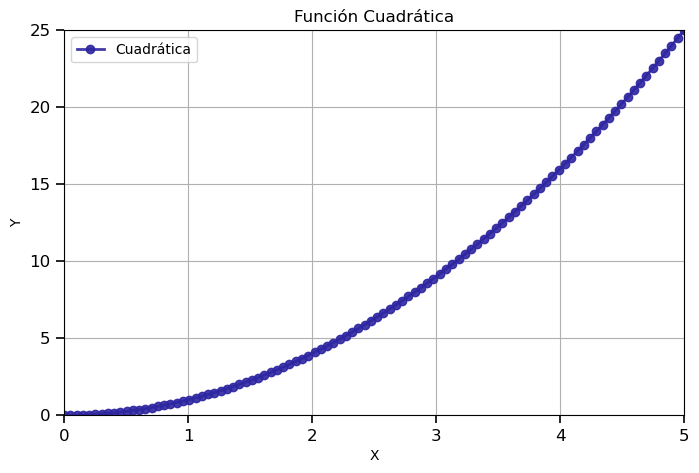

In [6]:
x = np.linspace(0, 5, 100)

fig, ax = plt.subplots(figsize=(8,5))

### Curva
ax.plot(x, 
        x**2,
        linewidth=2,
        linestyle="-",
        alpha=0.9,
        marker='o',
        markersize=6,
        color='#2E26A1',
        label="Cuadrática")

ax.set_title("Función Cuadrática")
ax.set_xlabel("X")
ax.set_ylabel("Y")

### Límites coherentes con los datos
ax.set_xlim(0, 5)
ax.set_ylim(0, 25)

### Ticks coherentes con los límites
ax.set_xticks(np.arange(0, 6, 1))
ax.set_yticks(np.arange(0, 26, 5))

### Parámetros de ticks
ax.tick_params(axis='both',
               labelsize=12,
               direction='out',
               length=6,
               width=1.2)

ax.legend()
ax.grid(True)

plt.show()

## Escalas Logarítmicas

* Las `escalas logarítmicas` son un tipo de escala donde los valores no crecen de forma lineal (1, 2, 3, 4…), sino por potencias (1, 10, 100, 1000…).
* En una escala normal (lineal):
  - La distancia entre 1 y 2 es igual que entre 9 y 10.
* En una escala logarítmica:
  - La distancia entre 1 y 10 es igual que entre 10 y 100.
  - Es decir, cada “salto” multiplica, no suma.
* ***¿Cuándo se usan?***
* Se usan cuando los datos:
  - Cubren varios órdenes de magnitud.
  - Crecen de forma exponencial.
  - Tienen valores muy pequeños y muy grandes al mismo tiempo.
* ***Visualmente***:
  - Las curvas exponenciales se "enderezan".
  - El crecimiento deja de verse explosivo.
  - Se puede apreciar mejor la tasa de crecimiento.
* ***¿Por qué se usa en Deep Learning?***
* En `Deep Learning`, la `loss` suele:
  - Empezar muy grande.
  - Disminuir rápidamente.
  - Luego estabilizarse en valores pequeños.
* ***¿Qué pasa con valores negativos?***
  - `log` no está definido para valores negativos.
* Si tienes una curva que parece lineal en escala log...
* ***¿Qué tipo de crecimiento tiene realmente?***
  - En escala normal → es una línea recta.
  - En escala log → se curva.
  - Porque estás aplicando log a algo que crece linealmente.
  - Ahora para una exponencial
  - En escala normal → parece explosivo.
  - En escala log → se vuelve recta.

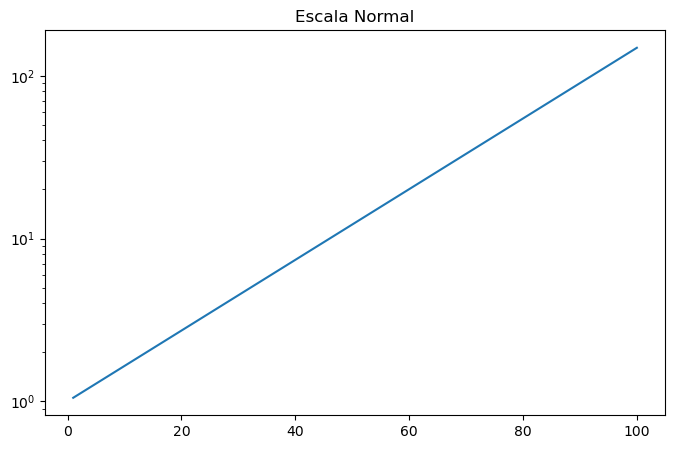

In [7]:
x = np.linspace(1, 100, 100)
y = np.exp(x / 20)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(x, y)

### Se agrega
ax.set_yscale("log")

ax.set_title("Escala Normal")
plt.show()

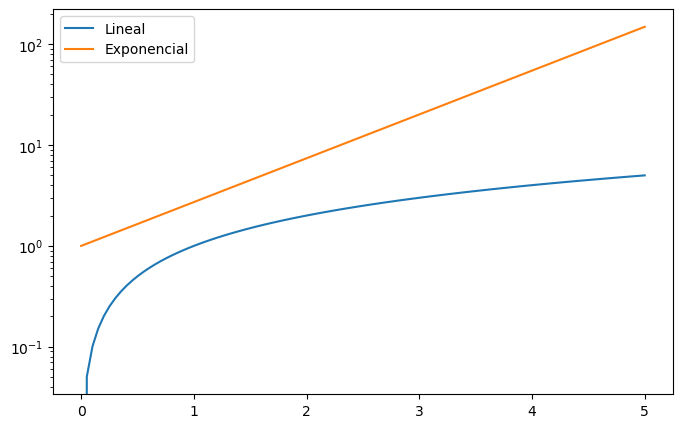

In [8]:
x = np.linspace(0, 5, 100)

y1 = x
y2 = np.exp(x)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(x, y1, label="Lineal")
ax.plot(x, y2, label="Exponencial")

### Aplicamos LOG
ax.set_yscale("log")

ax.legend()
plt.show()

## SCATTER PLOTS

* `ax.scatter(x, y)` : diagrama de puntos.
* ***¿Por qué scatter es tan importante?***
* Porque permite ver:
  - Relación entre variables.
  - Linealidad.
  - Outliers.
  - Heterocedasticidad.
  - Clusters.
  - Separabilidad
* Es la base del análisis previo a modelos.

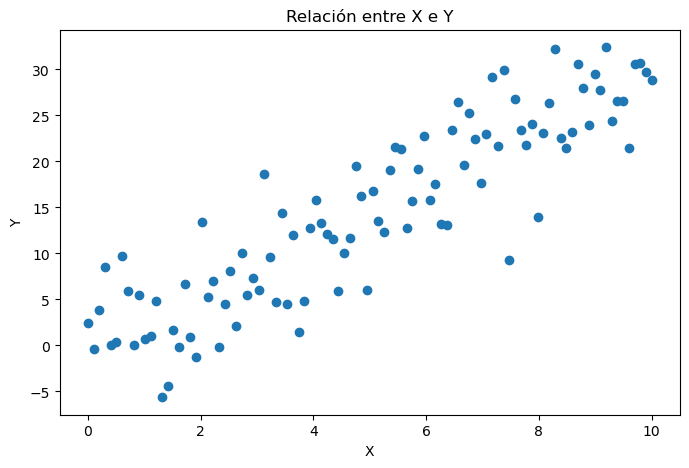

In [38]:
### Fijamos la muestra
np.random.seed(42)

x = np.linspace(0, 10, 100)
y = 3*x + np.random.normal(0, 5, 100)

fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(x, y)

ax.set_title("Relación entre X e Y")
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()

* `ax.scatter?` revisar documentación del `scatter`.
* ***Linea de tendencia***
```python
coef = np.polyfit(x, y, 1)
y_pred = coef[0]*x + coef[1]
ax.plot(x, y_pred)
```
* Podrías hacerlo más claro así:
```python
m, b = np.polyfit(x, y, 1)
y_pred = m*x + b
```
* `polyfit` es una función de `NumPy` que sirve para ajustar un polinomio a un conjunto de datos.
* En otras palabras, ***encuentra la ecuación matemática*** que mejor aproxima la relación entre `X` e `Y`.

***NOTAS***
* Generamos los datos como : $y = 3x + \text{ruido}$.
* Eso es un modelo linea con ruido Gaussiano.
* Visualmente:
  - Tendencia ascendente.
  - Nube de puntos alrededor de una línea.
  - Relación aproximadamente lineal.
* Un `scatter plot` bien hecho ya permite ver outliers.
* Un outlier en regresión es:
  - Un punto muy alejado verticalmente (residual grande)
  - O muy extremo en X (punto influyente)
* En `regresión lineal` clásica asumimos:
  - Los errores tienen varianza constante.
  - Eso se llama ***homocedasticidad***.
* La varianza formalmente es: $Var(X) = E[(X - \mu)^2]$
* ***¿Cómo se ve heterocedasticidad?***
* En un `scatter`:
  - Si la nube tiene grosor constante → homocedástico.
  - Si la nube se abre como abanico → heterocedástico.
* Se va “abriendo” -> Eso indica que la varianza aumenta con X.

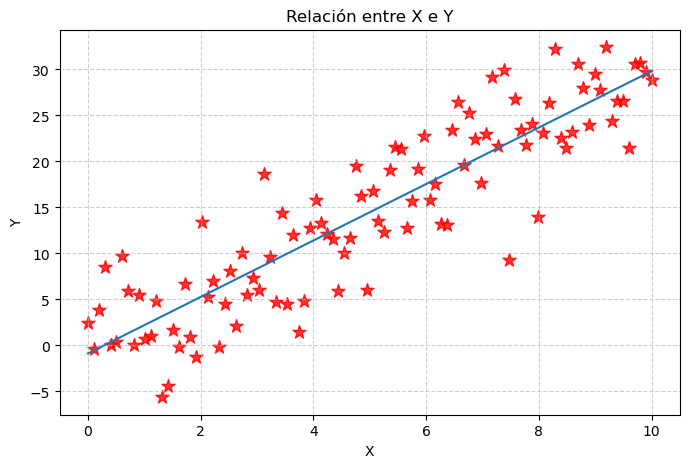

In [19]:
"""
1. Cambia tamaño de puntos (s=)
2. Cambia transparencia (alpha=)
3. Cambia color
4. Agrega grid
5. Agrega línea de tendencia manual:
"""
### Fijamos la muestra
np.random.seed(42)

x = np.linspace(0, 10, 100)
y = 3*x + np.random.normal(0, 5, 100)

fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(x, 
           y,
           s=100,
           c="red",
           marker="*",
           alpha=0.8
          )

### Linea de tendencia manual
coef = np.polyfit(x, y, 1)
y_pred = coef[0]*x + coef[1]
ax.plot(x, y_pred)

ax.set_title("Relación entre X e Y")
ax.set_xlabel("X")
ax.set_ylabel("Y")

### Agregamos el grid más estetico
### ax.grid(True)
ax.grid(True, linestyle="--", alpha=0.6)

plt.show()

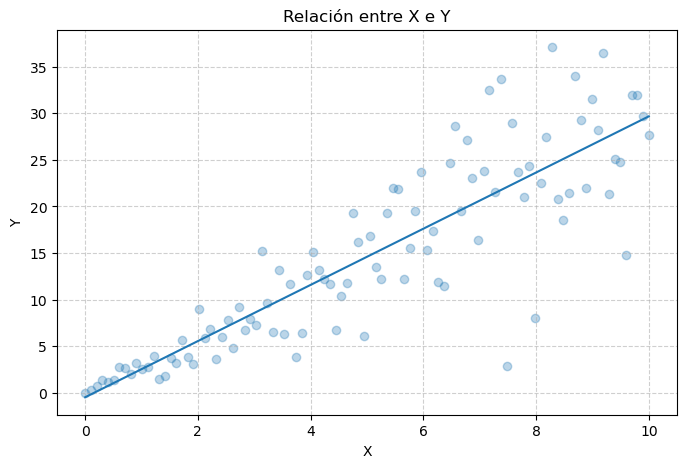

In [24]:
### Fijamos la muestra
np.random.seed(42)

x = np.linspace(0, 10, 100)
y = 3*x + np.random.normal(0, x, 100)

fig, ax = plt.subplots(figsize=(8,5))

# ax.scatter(x, 
#            y,
#            s=100,
#            c="green",
#            marker=".",
#            alpha=0.8
#           )
### Gradiente calor
# ax.scatter(x, 
#            y,
#            s=100,
#            c=x,
#            cmap="coolwarm",
#            marker=".",
#            alpha=0.8
#           )
ax.scatter(x, y, alpha=0.3)

### Linea de tendencia manual
coef = np.polyfit(x, y, 1)
y_pred = coef[0]*x + coef[1]
ax.plot(x, y_pred)

ax.set_title("Relación entre X e Y")
ax.set_xlabel("X")
ax.set_ylabel("Y")

### Agregamos el grid más estetico
### ax.grid(True)
ax.grid(True, linestyle="--", alpha=0.6)

plt.show()

## EJERCICIO SCATTER

* Esto del abanico se llama `ruido con varianza variable`.
* $y = 2x + \text{Ruido con Varianza Creciente}$
* El ruido ahora depende de `X`.
* El segundo parámetro es la desviación estándar `y = 2*x + np.random.normal(0, x, 200)`.
* Eso es ***heterocedasticidad*** visual pura.
* ***¿Qué cambia cuando agregas la línea?***
* Sin la línea:
  - Ves puntos dispersos.
  - Intuyes una tendencia.
* Con la línea:
  - Ves claramente qué tan lejos están los puntos del modelo.
  - Ves que la dispersión aumenta conforme crece X.
  - El cerebro empieza a pensar en “errores” (aunque no lo llames así).

* Recordemos qué minimiza mínimos cuadrados:
$$\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

* El problema es que en tu dataset el ruido crece con `X`.
* Eso significa que:
  - Para valores pequeños de `X` → errores pequeños.
  - Para valores grandes de `X` → errores grandes.
  - Y como están al cuadrado… pesan muchísimo más.
* El modelo va a intentar ajustarse mejor a la parte donde los errores son grandes (es decir, cuando X es grande).
* Eso puede provocar:
  - Que la pendiente estimada se incline ligeramente hacia los puntos grandes.
  - Que el modelo no represente tan bien la zona de X pequeños.
* Este fenómeno se llama:
  - `Heterocedasticidad` (varianza no constante del error).

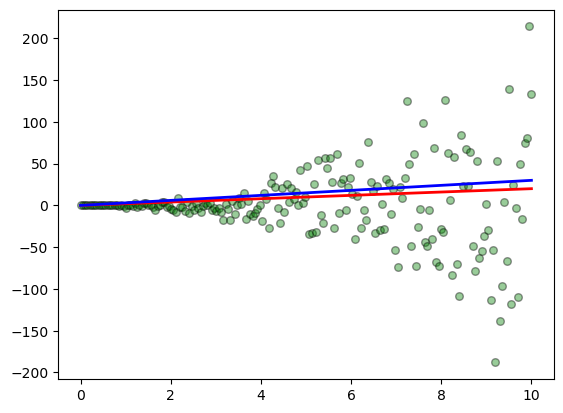

In [46]:
np.random.seed(0)

x = np.linspace(0, 10, 200)

#y = 2*x + np.random.normal(0, 3, 200)

### Eso hará que la dispersión crezca con X (forma de abanico).
#y = 2*x + np.random.normal(0, x, 200)

### Supongamos que no hay ruido
y = np.random.normal(0, x**2, 200)

plt.scatter(x,
            y,
            s=30,
            alpha=0.4,
            c="green",
            edgecolors="black", ## bordes
            linewidths=1 ## Grosor
           )
### Ahora graficamos y=2x y y=3x.
plt.plot(x, 2*x, color="red", linewidth=2)
plt.plot(x, 3*x, color="blue", linewidth=2)
### Funciona mejor 2x ya que comparte base para la generacion y=2*x

plt.show()

## Formatos al Graficar

### Creación de Gráficasde Líneas (plot)

* `plt` por si solo es un lienzo en blanco.
* nosotros podemos pintar las 'n' cantidades de datos que queramos. 

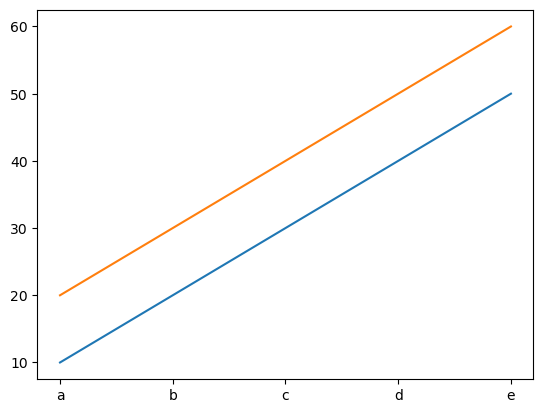

In [27]:
eje_x = ["a", "b", "c", "d", "e"]
datos1 = [10,20,30,40,50]
datos2 = [20,30,40,50,60]

### Cargamos los datos.
plt.plot(eje_x, datos1)
#plt.show()

plt.plot(eje_x, datos2)
#plt.show()
# Con este se imprimen los 2, si ponemos show 2 veces generará 2 gráficas.
plt.show()

### Generar Datos a Gráficar

Examen de certificación para estudiantes de 5 niveles.

***NOTAS***
* `np.random.rand(10)*100` : esta línea, nos trae una lista de 10 con valores entre 0 y 1.

In [28]:
años = ["2011", "2012", "2013", "2014", "2015",
        "2016", "2017", "2018", "2019", "2020"]
# Datos que se diferencien.
nivel1 = np.random.rand(10)*100
nivel2 = np.random.rand(10)*200+100
nivel3 = np.random.rand(10)*300+200
nivel4 = np.random.rand(10)*400+300
nivel5 = np.random.rand(10)*500+400

### Personalización de Gráficas

* `plt.legend()` : literal activa la descripción de las etiquetas.
* `plt.yticks(np.arange(0,1001,50))`: Ponemos que la escala sea de 0 a 1001, recordemos que este ultimo no se toma, además ponemos que sea de 50 en 50.

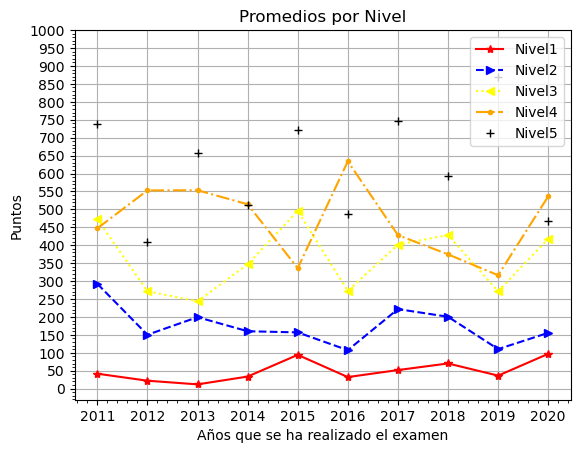

In [29]:
# Introducir series de datos con color, marcador y estilos
# Los colores pueden ser puestos hexadecimal o en su nombre
# Para los marcadores, podemos usar casi cualquier caracter del teclado
plt.plot(años,nivel1, label="Nivel1", color="red", marker = "*", linestyle="-")
plt.plot(años,nivel2, label="Nivel2", color="blue", marker = ">", linestyle="--")
plt.plot(años,nivel3, label="Nivel3", color="yellow", marker = "<", linestyle=":")
plt.plot(años,nivel4, label="Nivel4", color="orange", marker = ".", linestyle="-.")
plt.plot(años,nivel5, label="Nivel5", color="black", marker = "+", linestyle=" ") # No linea solo puntos

# Por default no incluye las equiquetas, hay que activarlas
plt.legend()
# Ponemos un titulo a la gráfica.
plt.title("Promedios por Nivel")

# Ponemos titulos a los eje
plt.xlabel("Años que se ha realizado el examen")
plt.ylabel("Puntos")

# Personalizar la escala del puntaje
plt.yticks(np.arange(0,1001,50))

# La cruadrícula viene desactiva por defecto, pero podemos activarla
plt.grid()

# E igualmente se pueden activar los ticks menores
plt.minorticks_on()

# Mostramos el lienzo final
plt.show()

### Gráficas de Barras Verticales (Bar)

* Si solos los graficamos así `plt.bar(eje_x,nivel5)` saldrán empalmados.
* Para poder verlas tenemos que desfazar, ya que todas gráfican en el punto 0.
* Así mismo tenemos que modificar la anchura de la barra

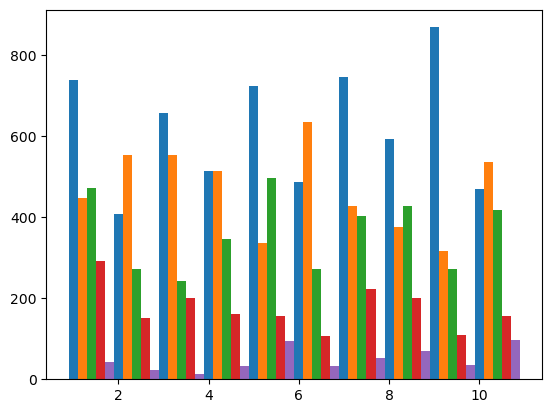

In [30]:
# Numeramos del 1 al 10
eje_x = np.arange(1,11)

plt.bar(eje_x,nivel5, width = 1/5)
plt.bar(eje_x+0.2,nivel4, width = 1/5)
plt.bar(eje_x+0.4,nivel3, width = 1/5)
plt.bar(eje_x+0.6,nivel2, width = 1/5)
plt.bar(eje_x+0.8,nivel1, width = 1/5)
plt.show()

### Gráficas de Barras Horizontales (barh)

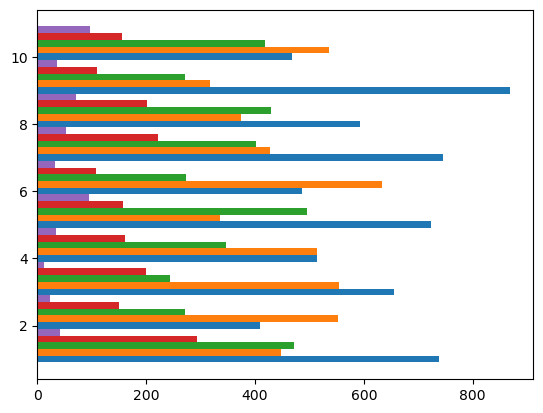

In [31]:
plt.barh(eje_x,nivel5, height = 1/5)
plt.barh(eje_x+0.2,nivel4, height = 1/5)
plt.barh(eje_x+0.4,nivel3, height = 1/5)
plt.barh(eje_x+0.6,nivel2, height = 1/5)
plt.barh(eje_x+0.8,nivel1, height = 1/5)
plt.show()

### Gráficas de Barras Verticales Apiladas

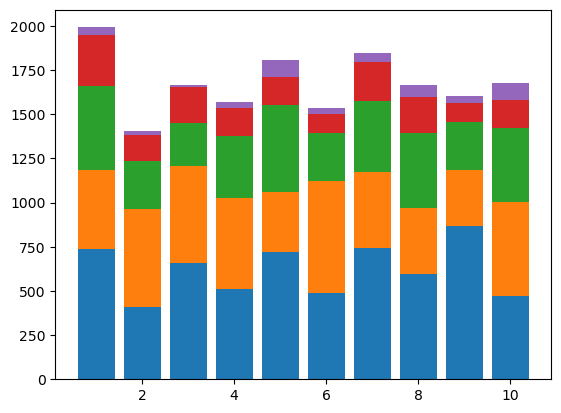

In [32]:
plt.bar(eje_x,nivel5)
plt.bar(eje_x,nivel4, bottom = nivel5)
plt.bar(eje_x,nivel3, bottom = nivel4+nivel5)
plt.bar(eje_x,nivel2, bottom = nivel3+nivel4+nivel5)
plt.bar(eje_x,nivel1, bottom = nivel2+nivel3+nivel4+nivel5)
plt.show()

### Gráfica de Dipersión (scatter)

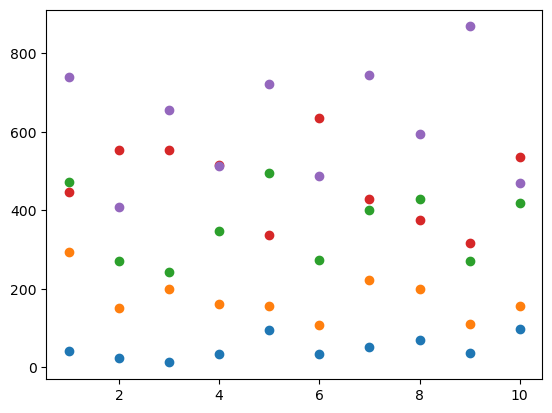

In [33]:
# Dispersión de puntos
plt.scatter(eje_x,nivel1)
plt.scatter(eje_x,nivel2)
plt.scatter(eje_x,nivel3)
plt.scatter(eje_x,nivel4)
plt.scatter(eje_x,nivel5)
plt.show()

### Gráfica de Pie

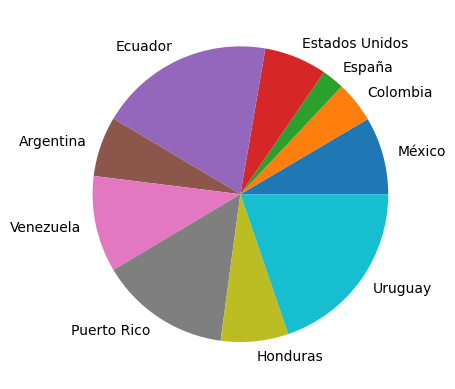

In [34]:
plt.pie(nivel1,
       labels = [
           "México", "Colombia", "España", "Estados Unidos", "Ecuador",
           "Argentina", "Venezuela", "Puerto Rico", "Honduras", "Uruguay"
       ])
plt.show()

### Combinar gráficas

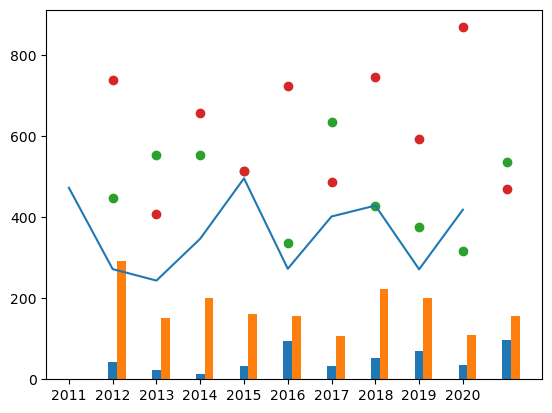

In [35]:
plt.bar(eje_x, nivel1, width = 1/5)
plt.bar(eje_x+0.2, nivel2, width = 1/5)

plt.plot(años, nivel3)

plt.scatter(eje_x,nivel4)
plt.scatter(eje_x,nivel5)
plt.show()